# Exercício 6 — Indicadores, visualização e storytelling (Projeto 2)

Este exercício continua o **Projeto 2**. Ele pega a tabela-resumo por hashtag que você já construiu na Aula 5 (com a sua própria coleta, ou o recorte que você escolheu) e acrescenta pelo menos **duas visualizações** a essa análise.

Siga as partes em ordem: cada uma depende do resultado da anterior. Onde houver `# complete aqui`, é o trecho que falta você escrever; o resto já está pronto.

In [32]:
import altair as alt

## Preparação do ambiente

Como este notebook mora numa pasta própria (dentro da sua pasta de entregas), use o `.venv` da **raiz do seu repositório de trabalhos** (o mesmo das outras entregas). Não precisa criar um `.venv` novo dentro de `exercicios/`.

Na raiz do repositório de trabalhos, instale as dependências deste exercício (precisa de `pandas` e `matplotlib`):

```cmd
uv pip install -r projetos/05-metricas-exploracao/exercicios/requirements.txt
```

(Ajuste o caminho se a pasta da entrega tiver outro nome. Se você copiou a pasta `exercicios/` da Aula 6, o arquivo é o `requirements.txt` que veio junto dela.)

Se o `uv` não funcionar, use `pip install -r ...` com o ambiente já ativado.


## Parte 0 — Dados e pergunta

**Fonte dos dados:** copie a mesma coleta (ou recorte) que você usou no exercício da Aula 5 pra `dados/exportacao.csv` dentro desta pasta. Se você já tem `dados/resumo_hashtags.csv` salvo do exercício anterior, pode reaproveitar, mas o roteiro abaixo refaz a tabela do zero pra garantir que está tudo atualizado.

**Pergunta que a visualização vai responder:** você já tinha uma pergunta analítica na Aula 5. Ela pode continuar a mesma, ou você pode escolher uma nova pergunta que fique mais clara com gráfico do que com tabela. Exemplos no espírito desta aula:

- "quais hashtags se destacam em engajamento médio (e quantos posts cada uma teve)?"
- "o engajamento médio variou muito entre os dias da coleta?"
- "contas com mais seguidores têm taxa de engajamento maior ou menor nesta coleta?"

Anote aqui antes de seguir:

**Pergunta escolhida:**

> Vídeos de tutorial de maquiagem perfoam melhor do que vídeos de arrume-se comigo (grwm)?

**Por que um gráfico ajuda a responder essa pergunta melhor que a tabela sozinha:**

> O tutorial de maquiagem foi um dos estilos de conteúdos mais bombados no ínicio das redes sociais, principalmente no Youtube. Com o tempo, e com a popularidade do TikTok, a trend GRWM (arrume-se comigo) se tornou um dos conteúdos mais bombados e também um dos modelos que fez com que influencers teens, como a Tozetto, Liz Macedo, Antonela Braga, Júlia Pimentel e Soso Careca estourassem nas redes. Mas será que depois de todo esse tempo os GRWM ainda são conteúdos que bombam ou será que os usuários voltaram a preferir assistir a tutoriais, que são de fato úteis?


## Parte 1 — Carregar e refazer a tabela-resumo

Carregue o CSV e refaça o pipeline da Aula 5/6: remover duplicata, filtrar visualização zero, calcular taxa de engajamento, explodir hashtags e agrupar. Esse trecho já vem pronto, igual ao que foi feito em aula, só ajuste os nomes de coluna se a sua plataforma usar nomes diferentes.

In [33]:
import pandas as pd  # pandas pra tabela
import matplotlib.pyplot as plt  # matplotlib pra gráfico

df = pd.read_csv("/Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/06-vizualizacao-storytelling/06-visualizacao-storytelling/dados/zeeschuimer-export-tiktok.com-2026-08-19T150132.csv", sep=";")  # lê a exportação
df = df.drop_duplicates()  # remove duplicata, se houver

print(f"Linhas depois de remover duplicatas: {len(df)}")

Linhas depois de remover duplicatas: 1416


In [34]:
df_posts = df[df["plays"] > 0].copy()  # só posts com denominador válido (ajuste o nome da coluna se necessário)

df_posts["taxa_engajamento"] = (
    df_posts["likes"] + df_posts["comments"] + df_posts["shares"]
) / df_posts["plays"]  # mesma fórmula da aula: interações dividido por visualizações

print(f"Posts com visualização válida: {len(df_posts)}")

Posts com visualização válida: 1416


In [35]:
df_hashtags = df_posts.dropna(subset=["hashtags"]).copy()  # só posts com hashtag preenchida
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.split(",")  # separa a string em lista
df_hashtags = df_hashtags.explode("hashtags")  # uma linha por hashtag
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.strip().str.lower()  # tira espaço e padroniza minúsculas
df_hashtags = df_hashtags[df_hashtags.groupby("hashtags")["id"].transform("count") >= 20]

resumo_hashtags = df_hashtags.groupby("hashtags").agg(  # agrupa por hashtag
    qtd_posts=("id", "count"),
    curtidas_medias=("likes", "mean"),
    engajamento_medio=("taxa_engajamento", "mean"),
    data=("timestamp", "min")
).reset_index().sort_values("engajamento_medio", ascending=False)

resumo_hashtags.head(10)


,hashtags,qtd_posts,curtidas_medias,engajamento_medio,data
11,grwm,178,210196.219101,0.112735,2023-02-07 23:04:28
12,grwmmakeup,26,54408.500000,0.088932,2023-02-07 23:04:28
0,arrumesecomigo,26,35048.615385,0.086875,2023-02-07 23:04:28
10,girls,36,320362.277778,0.085843,2023-05-04 09:00:20
7,fy,86,143747.255814,0.083426,2022-09-14 01:40:11
9,fypシ,38,97386.789474,0.078811,2023-07-29 22:45:11
8,fyp,342,182275.336257,0.077419,2022-06-22 22:54:47
3,creatorsearchinsights,44,17539.636364,0.074360,2024-10-17 15:11:42
26,tutorial,110,204248.663636,0.073321,2022-07-13 03:19:01
5,foryou,145,163638.441379,0.073165,2023-02-07 23:04:28


## Parte 2 — Primeira visualização: gráfico de barras

Monte um gráfico de barras comparando `engajamento_medio` entre hashtags (um recorte tipo `.head(10)` ajuda a leitura), no mesmo espírito da Seção 5 da aula: figura com tamanho legível, título informativo, rótulos nos dois eixos e a fonte dos dados escrita no gráfico.

**OBS:** o topo por engajamento médio costuma misturar hashtags com poucos posts. Vale olhar também a coluna `qtd_posts` da tabela antes de interpretar.


/var/folders/ff/tkpv575n2xbdwzn_lq91pct00000gp/T/ipykernel_19107/446234242.py:26: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/ff/tkpv575n2xbdwzn_lq91pct00000gp/T/ipykernel_19107/446234242.py:27: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.savefig("/Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/06-vizualizacao-storytelling/06-visualizacao-storytelling/dados/grafico_top5_hashtags.png", dpi=120, bbox_inches="tight")  # salva a figura para poder anexar no relatório
/Users/leonardorosa/estudo/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


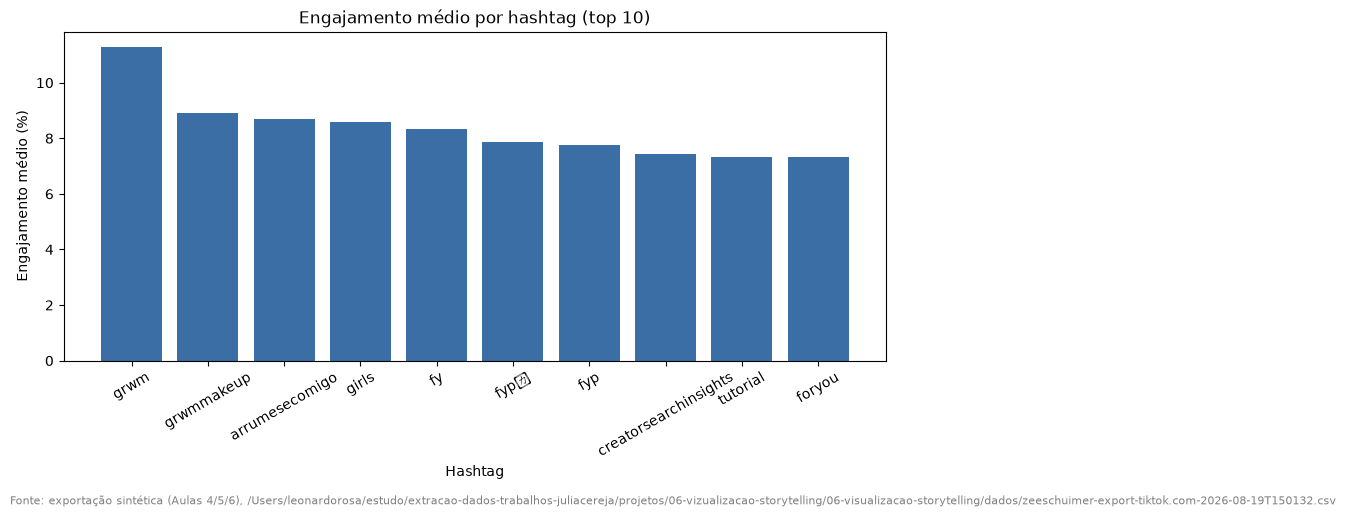

In [36]:
# complete aqui: monte um gráfico de barras com plt.subplots(), comparando uma métrica (ex.: engajamento_medio)
# entre as hashtags de resumo_hashtags (ou um recorte dela, como .head(10))
#
# checklist do gráfico (confira todos antes de seguir):
# - fig, ax = plt.subplots(figsize=(largura, altura))
# - ax.bar(...) com as hashtags no eixo X e a métrica escolhida no eixo Y
# - ax.set_title("...") com um título que descreve o que o gráfico mostra
# - ax.set_xlabel("...") e ax.set_ylabel("...") com nomes claros (e unidade, se fizer sentido)
# - fig.text(...) com a fonte dos dados
# - fig.tight_layout() e plt.show() no final
df_hashtags = df_hashtags[df_hashtags.groupby("hashtags")["id"].transform("count") >= 20]
resumo_hashtags = df_hashtags.groupby("hashtags").agg(  # agrupa por hashtag
    qtd_posts=("id", "count"),
    curtidas_medias=("likes", "mean"),
    engajamento_medio=("taxa_engajamento", "mean"),
).reset_index().sort_values("engajamento_medio", ascending=False) 
top10 = resumo_hashtags.head(10)  # as 10 hashtags com maior engajamento médio, para o gráfico do relatório de exemplo

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(top10["hashtags"], top10["engajamento_medio"] * 100, color="#3b6ea5")
ax.set_title("Engajamento médio por hashtag (top 10)")
ax.set_xlabel("Hashtag")
ax.set_ylabel("Engajamento médio (%)")
ax.tick_params(axis="x", rotation=30)
fig.text(0.01, -0.02, "Fonte: exportação sintética (Aulas 4/5/6), /Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/06-vizualizacao-storytelling/06-visualizacao-storytelling/dados/zeeschuimer-export-tiktok.com-2026-08-19T150132.csv", fontsize=8, color="gray")
fig.tight_layout()
plt.savefig("/Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/06-vizualizacao-storytelling/06-visualizacao-storytelling/dados/grafico_top5_hashtags.png", dpi=120, bbox_inches="tight")  # salva a figura para poder anexar no relatório
plt.show()



**Interpretação do gráfico de barras, em texto:**

> O que esse gráfico mostra? Qual hashtag ficou no topo? Quantos posts ela teve (`qtd_posts`)? O que o gráfico **permite** concluir nesta coleta, e o que ele **NÃO** permite (lembre: engajamento médio alto com 1 post não generaliza; volume e desempenho relativo são perguntas diferentes)?

Esse gráfico mostra que a #grwm e #grwmmakeup tem muito mais engajamento do que a #tutorial, visto que ficaram no topo. A #grwm teve 178 posts já a #tutorial 110. O gráfico nos permite concluir que os vídeos de grwm performam melhor dentro dessa coleta, visto que a taxa de engajamento da #grwm é de 0.11 e a #tutorial 0.07. Porém não nos permite concluir de forma concreta se necessariamente um vídeo de maquigem que use a #grwm vai performar melhor.

## Parte 3 — Segunda visualização: linha ou dispersão

Escolha **um** dos dois roteiros abaixo (o que fizer mais sentido pra sua pergunta da Parte 0) e monte o gráfico correspondente. Os dois seguem o que foi feito nas Seções 6 e 7 da aula.


### Opção A — Gráfico de linhas (evolução no tempo)

Use se sua coleta tem posts em datas diferentes e você quer ver o engajamento (ou outra métrica) variar ao longo do tempo.

**OBS:** se a coleta misturar datas muito antigas com datas recentes, o eixo fica esmagado (igual vimos na aula). Nesse caso, filtre o período antes de plotar, comparando `date` com `date` (não com texto):

```python
engajamento_por_dia = engajamento_por_dia[
    engajamento_por_dia["data_coleta"] >= pd.to_datetime("2026-01-01").date()
]
```

(Ajuste a data de corte ao que fizer sentido na **sua** coleta.)


          mes  hashtags  taxa_engajamento
0  2022-07-01  tutorial          0.026690
1  2022-11-01  tutorial          0.076928
2  2023-02-01      grwm          0.019577
3  2023-03-01  tutorial          0.027712
4  2023-04-01      grwm          0.065061
..        ...       ...               ...
61 2026-06-01  tutorial          0.029511
62 2026-07-01      grwm          0.124698
63 2026-07-01  tutorial          0.078590
64 2026-08-01      grwm          0.118724
65 2026-08-01  tutorial          0.101686

[66 rows x 3 columns]


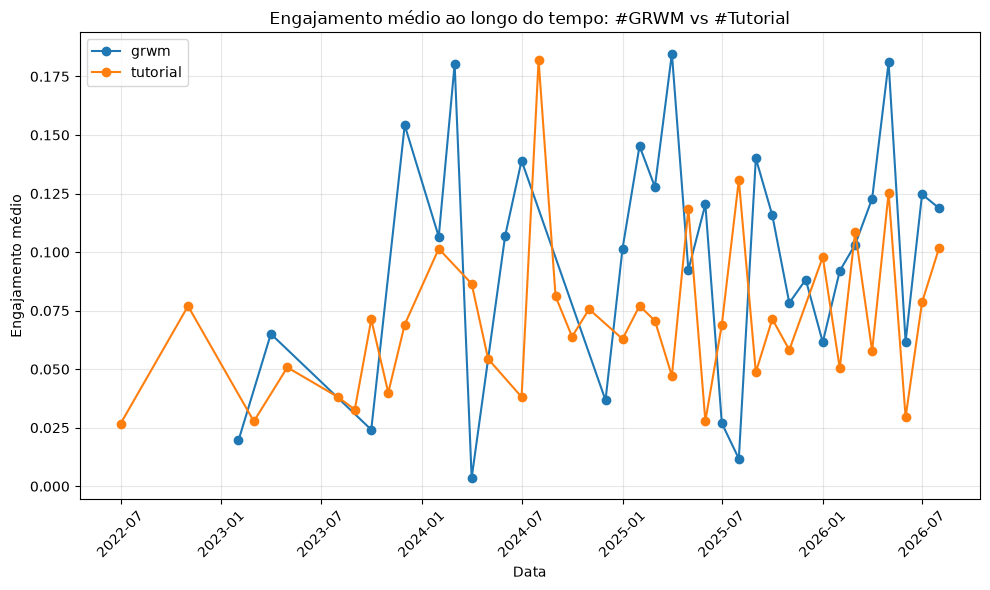

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Remover posts sem visualizações
df_hashtags = df_hashtags[df_hashtags["plays"] > 0].copy()

# Calcular taxa de engajamento
df_hashtags["taxa_engajamento"] = (
    df_hashtags["likes"]
    + df_hashtags["comments"]
    + df_hashtags["shares"]
) / df_hashtags["plays"]

# Converter timestamp para data
df_hashtags["timestamp"] = pd.to_datetime(
    df_hashtags["timestamp"]
)

# Criar coluna de mês
df_hashtags["mes"] = (
    df_hashtags["timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Selecionar somente GRWM e Tutorial
comparacao = df_hashtags[
    df_hashtags["hashtags"].isin(["grwm", "tutorial"])
].copy()

# Calcular engajamento médio por mês
resumo_tempo = (
    comparacao
    .groupby(["mes", "hashtags"])["taxa_engajamento"]
    .mean()
    .reset_index()
)

# Mostrar os dados antes do gráfico
print(resumo_tempo)

# Criar gráfico
plt.figure(figsize=(10, 6))

for hashtag in ["grwm", "tutorial"]:

    dados = resumo_tempo[
        resumo_tempo["hashtags"] == hashtag
    ].sort_values("mes")

    plt.plot(
        dados["mes"],
        dados["taxa_engajamento"],
        marker="o",
        label=hashtag
    )

plt.title("Engajamento médio ao longo do tempo: #GRWM vs #Tutorial")
plt.xlabel("Data")
plt.ylabel("Engajamento médio")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/06-vizualizacao-storytelling/06-visualizacao-storytelling/dados/grafico_comparacao_hashtags.png", dpi=120, bbox_inches="tight") 

plt.show()

precisei usar IA aqui, pois queria comparar a taxa de engajamento das duas hashtags ao longo do tempo, para responder minha pergunta. :/ 

### Opção B — Gráfico de dispersão (relação entre duas variáveis)

Use se você quer ver a relação entre duas colunas numéricas, um ponto por post. O roteiro da aula foi: **seguidores do autor (`author_followers`) vs. taxa de engajamento (`taxa_engajamento`)**, com escala log no eixo X quando a diferença de tamanho entre contas for enorme.

Outros pares também valem (curtidas vs. comentários, plays vs. engajamento), desde que a pergunta da Parte 0 peça isso.


In [ ]:
# complete aqui, SE ESCOLHEU a opção B (gráfico de dispersão):
# 1. escolha duas colunas numéricas de df_posts (sugestão da aula: author_followers no X, taxa_engajamento*100 no Y)
# 2. monte com plt.subplots(), ax.scatter(..., alpha=0.6), título, rótulos e fonte dos dados
# 3. se os pontos amontoarem num canto (contas muito diferentes de tamanho), use ax.set_xscale("log")
# 4. fig.tight_layout() e plt.show() no final


**Interpretação do segundo gráfico, em texto:**

> O que esse gráfico mostra? Qual pergunta ele responde?
>
> Se foi **linha:** o engajamento variou como ao longo dos dias? Houve pico ou queda? O que o período filtrado (se houver) muda na leitura?
>
> Se foi **dispersão:** nesta coleta, contas com mais seguidores tendem a engajar mais, menos, ou parecido? A escala log ajudou a ler? O que o gráfico **permite** e o que ele **NÃO** permite (cuidado com causalidade)?

Esse gráfico mostra que a trend do grwm realmente foi um estouro e deu mais vizibilidade para muitas criadoress, já o tutorial continua dando certo, mas tem um engajamento menor. Então o grwm sobrevive ainda.

O engajamento variou muito ao longo do tempo, mas é notável que grwm teve muitos mais picos, mas também quedas muito bruscas. O período filtrado nos permite perceber que realmente a #grwm chegou depois. Antigamente os tutoriais eram muito procurados e bombados, e eles continuam dando resultado de uma forma mais constante, diferente do GRWM que tem mais picos de engajamento. Apesar disso, o gráfico não nos permite concluir que uma tomou o espaço da outra.

## Parte 4 — Conferir contra a pergunta da Parte 0

Releia a pergunta que você escreveu na Parte 0. Os dois gráficos que você montou respondem essa pergunta? Se a resposta for "só em parte" ou "não", ajuste a pergunta ou o gráfico antes de seguir, não force uma conclusão que os dados não sustentam.

**Resposta final à pergunta, com base nos dois gráficos:**

Os gráfico respondem a minha pergunta, o prim eiro mostra que a #grwm teve mais engajamento total e o segundo gráfico comprova o que eu disse sobre o tutorial ter vindo antes na internet mas o grwm teve mais picos de engajamento, que foi o que fez as teens bombarem. E o engajamento permanece até hoje, então não foi uma trend esquecida.

## Parte 5 — Documentação no README

Atualize `projetos/05-metricas-exploracao/README.md` (na sua pasta de entregas, o mesmo README do Projeto 2 que você já tinha da Aula 5) acrescentando:

**Gráfico 1 (barras) — pergunta que ele responde:**

> Escreva aqui.

**Gráfico 2 (linha ou dispersão) — pergunta que ele responde:**

> Escreva aqui.

**Declaração de uso de IA:** ferramenta usada, em que trecho ou decisão desta entrega, e o que você conferiu ou alterou depois do resultado gerado (mesmo que a resposta seja "não usei IA nesta entrega", registre isso).

## Parte 6 — Conferência final

Antes de considerar a entrega concluída, confira:

- [ ] `dados/exportacao.csv` é a mesma coleta (ou recorte) usada no exercício da Aula 5, e a pasta `dados/` está no `.gitignore`.
- [ ] A Parte 1 rodou sem erro e recriou a tabela-resumo por hashtag (com hashtags em minúsculas, se você padronizou).
- [ ] O gráfico de barras da Parte 2 tem título informativo, rótulos nos dois eixos e a fonte dos dados escrita nele.
- [ ] O segundo gráfico da Parte 3 (linha ou dispersão) também tem título, rótulos e fonte; se foi linha com filtro de data, a comparação usou `.date()` (não string solta).
- [ ] As duas interpretações em texto (Partes 2 e 3) dizem o que o gráfico mostra E o que ele não permite concluir.
- [ ] A Parte 4 responde à pergunta da Parte 0 sem extrapolar além da evidência.
- [ ] `projetos/05-metricas-exploracao/README.md` foi atualizado com a pergunta de cada gráfico e a declaração de uso de IA.
- [ ] O notebook roda do início ao fim sem erro usando Kernel → Restart e Run All (ou o equivalente no VS Code), não só célula por célula fora de ordem.
- [ ] Esse notebook está copiado dentro de `projetos/05-metricas-exploracao/` na sua pasta de entregas.
- [ ] Você já fez `git add`, `git commit` e `git push` dessa entrega.
